In [ ]:
from google.colab import files
uploaded = files.upload()

file_path = list(uploaded.keys())[0]
print("Uploaded file:", file_path)

Saving Load House 1.csv to Load House 1.csv
Uploaded file: Load House 1.csv


In [ ]:
import math
import copy
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


Original shape: (111068, 6)


,Date,Hour,Day of the Week,Season,Daytime,Consumption (kW)
0,2021-03-01,00:00:00,0,1,0,0.096
1,2021-03-01,00:15:00,0,1,0,0.196
2,2021-03-01,00:30:00,0,1,0,0.128
3,2021-03-01,00:45:00,0,1,0,0.156
4,2021-03-01,01:00:00,0,1,0,0.096


Cleaned 15-min shape: (111073, 2)
datetime       0
consumption    0
dtype: int64

15-min gap check:
datetime
0 days 00:15:00    111072
Name: count, dtype: int64

Hourly shape: (27769, 2)


,datetime,consumption
0,2021-03-01 00:00:00,0.144
1,2021-03-01 01:00:00,0.075
2,2021-03-01 02:00:00,0.126
3,2021-03-01 03:00:00,0.063
4,2021-03-01 04:00:00,0.082



Hourly gap check:
datetime
0 days 01:00:00    27768
Name: count, dtype: int64


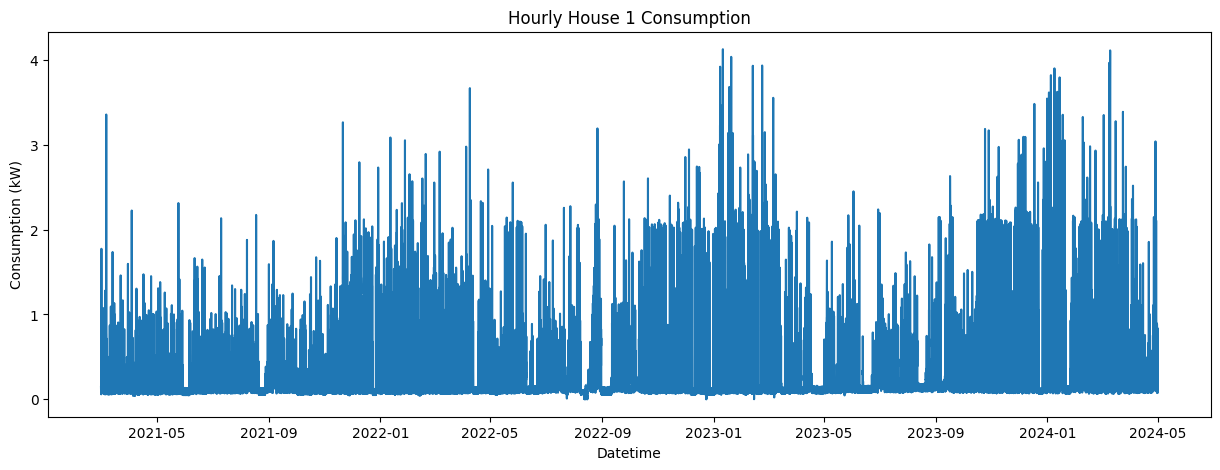

In [ ]:
# =========================
# 1. Load and clean dataset
# =========================

df = pd.read_csv(file_path)

print("Original shape:", df.shape)
display(df.head())

df["datetime"] = pd.to_datetime(df["Date"] + " " + df["Hour"])
df = df.sort_values("datetime").reset_index(drop=True)

data = df[["datetime", "Consumption (kW)"]].copy()
data.rename(columns={"Consumption (kW)": "consumption"}, inplace=True)

# combine duplicate timestamps
data = data.groupby("datetime", as_index=False)["consumption"].mean()

# create complete 15-min timeline
full_time = pd.date_range(
    start=data["datetime"].min(),
    end=data["datetime"].max(),
    freq="15min"
)

data = data.set_index("datetime").reindex(full_time)
data.index.name = "datetime"

# fill missing values
data["consumption"] = data["consumption"].interpolate(method="time")
data["consumption"] = data["consumption"].ffill().bfill()

data = data.reset_index()

print("Cleaned 15-min shape:", data.shape)
print(data.isnull().sum())

print("\n15-min gap check:")
print(data["datetime"].diff().value_counts().head())

# resample to hourly
hourly_data = data.set_index("datetime").resample("1h").mean()
hourly_data = hourly_data.interpolate(method="time")
hourly_data = hourly_data.ffill().bfill()
hourly_data = hourly_data.reset_index()

print("\nHourly shape:", hourly_data.shape)
display(hourly_data.head())

print("\nHourly gap check:")
print(hourly_data["datetime"].diff().value_counts().head())

plt.figure(figsize=(15, 5))
plt.plot(hourly_data["datetime"], hourly_data["consumption"])
plt.title("Hourly House 1 Consumption")
plt.xlabel("Datetime")
plt.ylabel("Consumption (kW)")
plt.show()

In [ ]:
# =========================
# 2. Informer configuration
# =========================

# Same long-history situation as your TimeBase experiment
SEQ_LEN = 720      # encoder input: past 720 hours = 30 days
LABEL_LEN = 96     # decoder gets last 96 known hours
PRED_LEN = 96      # predict next 96 hours = 4 days

BATCH_SIZE = 16    # reduce to 8 if CUDA memory issue
EPOCHS = 20
PATIENCE = 5
LR = 1e-4

D_MODEL = 64
N_HEADS = 4
E_LAYERS = 2
D_LAYERS = 1
D_FF = 128
DROPOUT = 0.1
FACTOR = 5

print("SEQ_LEN:", SEQ_LEN)
print("LABEL_LEN:", LABEL_LEN)
print("PRED_LEN:", PRED_LEN)

SEQ_LEN: 720
LABEL_LEN: 96
PRED_LEN: 96


In [ ]:
# =========================
# 3. Create time features
# =========================

dfh = hourly_data[["datetime", "consumption"]].copy()
dfh = dfh.sort_values("datetime").reset_index(drop=True)

dt = dfh["datetime"]

dfh["hour_sin"] = np.sin(2 * np.pi * dt.dt.hour / 24)
dfh["hour_cos"] = np.cos(2 * np.pi * dt.dt.hour / 24)

dfh["dow_sin"] = np.sin(2 * np.pi * dt.dt.dayofweek / 7)
dfh["dow_cos"] = np.cos(2 * np.pi * dt.dt.dayofweek / 7)

dfh["month_sin"] = np.sin(2 * np.pi * dt.dt.month / 12)
dfh["month_cos"] = np.cos(2 * np.pi * dt.dt.month / 12)

target_raw = dfh[["consumption"]].values.astype(np.float32)

n = len(dfh)
tr_end = int(n * 0.7)
va_end = int(n * 0.8)

scaler = StandardScaler()
scaler.fit(target_raw[:tr_end])

target_scaled = scaler.transform(target_raw).astype(np.float32)

time_features = dfh[
    ["hour_sin", "hour_cos", "dow_sin", "dow_cos", "month_sin", "month_cos"]
].values.astype(np.float32)

# feature matrix: [scaled consumption + known time features]
all_features = np.concatenate([target_scaled, time_features], axis=1).astype(np.float32)

INPUT_DIM = all_features.shape[1]
OUTPUT_DIM = 1

print("Total hourly points:", n)
print("Input dim:", INPUT_DIM)
print("Feature columns: scaled_consumption + 6 time features")
print("Train range:", dfh["datetime"].iloc[0], "to", dfh["datetime"].iloc[tr_end - 1])
print("Val range:", dfh["datetime"].iloc[tr_end], "to", dfh["datetime"].iloc[va_end - 1])
print("Test range:", dfh["datetime"].iloc[va_end], "to", dfh["datetime"].iloc[-1])

Total hourly points: 27769
Input dim: 7
Feature columns: scaled_consumption + 6 time features
Train range: 2021-03-01 00:00:00 to 2023-05-19 21:00:00
Val range: 2023-05-19 22:00:00 to 2023-09-12 14:00:00
Test range: 2023-09-12 15:00:00 to 2024-05-01 00:00:00


In [ ]:
# =========================
# 4. Train / val / test split
# =========================

# include SEQ_LEN history before val and test so first val/test forecast has enough context
train_x = all_features[:tr_end]
train_y = target_scaled[:tr_end]

val_x = all_features[tr_end - SEQ_LEN : va_end]
val_y = target_scaled[tr_end - SEQ_LEN : va_end]

test_x = all_features[va_end - SEQ_LEN :]
test_y = target_scaled[va_end - SEQ_LEN :]

print("Train:", train_x.shape, train_y.shape)
print("Val:", val_x.shape, val_y.shape)
print("Test:", test_x.shape, test_y.shape)

Train: (19438, 7) (19438, 1)
Val: (3497, 7) (3497, 1)
Test: (6274, 7) (6274, 1)


In [ ]:
# =========================
# 5. Dataset
# =========================

class InformerDataset(Dataset):
    def __init__(self, x, y, seq_len, label_len, pred_len):
        self.x = x.astype(np.float32)
        self.y = y.astype(np.float32)

        self.seq_len = seq_len
        self.label_len = label_len
        self.pred_len = pred_len

    def __len__(self):
        return len(self.x) - self.seq_len - self.pred_len + 1

    def __getitem__(self, i):
        s0 = i
        s1 = i + self.seq_len

        r0 = s1 - self.label_len
        r1 = s1 + self.pred_len

        x_enc = self.x[s0:s1]

        # decoder input = known label_len points + future time features
        x_dec = self.x[r0:r1].copy()

        # future consumption is unknown, so set it to zero
        x_dec[self.label_len:, 0] = 0.0

        y = self.y[s1:r1]

        return (
            torch.tensor(x_enc, dtype=torch.float32),
            torch.tensor(x_dec, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32)
        )


train_ds = InformerDataset(train_x, train_y, SEQ_LEN, LABEL_LEN, PRED_LEN)
val_ds = InformerDataset(val_x, val_y, SEQ_LEN, LABEL_LEN, PRED_LEN)
test_ds = InformerDataset(test_x, test_y, SEQ_LEN, LABEL_LEN, PRED_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

print("Train samples:", len(train_ds))
print("Val samples:", len(val_ds))
print("Test samples:", len(test_ds))

xb, xd, yb = next(iter(train_loader))
print("x_enc:", xb.shape)
print("x_dec:", xd.shape)
print("y:", yb.shape)

Train samples: 18623
Val samples: 2682
Test samples: 5459
x_enc: torch.Size([16, 720, 7])
x_dec: torch.Size([16, 192, 7])
y: torch.Size([16, 96, 1])


In [ ]:
# =========================
# 6. Informer-based model
# =========================

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=10000):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)

        div = torch.exp(
            torch.arange(0, d_model, 2).float()
            * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)

        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]


class DataEmbedding(nn.Module):
    def __init__(self, input_dim, d_model, dropout=0.1):
        super().__init__()
        self.value_embedding = nn.Linear(input_dim, d_model)
        self.position_embedding = PositionalEncoding(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.value_embedding(x)
        x = self.position_embedding(x)
        return self.dropout(x)


class ProbSparseSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads, factor=5, dropout=0.1):
        super().__init__()

        assert d_model % n_heads == 0

        self.d_model = d_model
        self.n_heads = n_heads
        self.d_head = d_model // n_heads
        self.factor = factor

        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x: [B, L, D]
        b, l, d = x.shape
        h = self.n_heads
        dh = self.d_head

        q = self.q_proj(x).reshape(b, l, h, dh).permute(0, 2, 1, 3)
        k = self.k_proj(x).reshape(b, l, h, dh).permute(0, 2, 1, 3)
        v = self.v_proj(x).reshape(b, l, h, dh).permute(0, 2, 1, 3)

        # q, k, v: [B, H, L, Dh]
        sample_k = min(l, max(1, self.factor * int(math.log(l + 1))))
        top_u = min(l, max(1, self.factor * int(math.log(l + 1))))

        # sample keys for each query
        idx = torch.randint(l, (l, sample_k), device=x.device)
        k_sample = k[:, :, idx, :]                  # [B, H, L, sample_k, Dh]
        q_exp = q.unsqueeze(3)                      # [B, H, L, 1, Dh]

        sample_scores = torch.sum(q_exp * k_sample, dim=-1) / math.sqrt(dh)
        sparsity = sample_scores.max(dim=-1).values - sample_scores.mean(dim=-1)

        top_idx = sparsity.topk(top_u, dim=-1).indices     # [B, H, top_u]

        q_top = torch.gather(
            q,
            dim=2,
            index=top_idx.unsqueeze(-1).expand(-1, -1, -1, dh)
        )

        scores = torch.matmul(q_top, k.transpose(-2, -1)) / math.sqrt(dh)
        attn = torch.softmax(scores, dim=-1)
        attn = self.dropout(attn)

        ctx_top = torch.matmul(attn, v)

        # initialize context with mean value
        ctx = v.mean(dim=2, keepdim=True).expand(b, h, l, dh).clone()

        ctx.scatter_(
            dim=2,
            index=top_idx.unsqueeze(-1).expand(-1, -1, -1, dh),
            src=ctx_top
        )

        out = ctx.permute(0, 2, 1, 3).reshape(b, l, d)
        return self.out_proj(out)


class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, factor=5, dropout=0.1):
        super().__init__()

        self.attn = ProbSparseSelfAttention(
            d_model=d_model,
            n_heads=n_heads,
            factor=factor,
            dropout=dropout
        )

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model)
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        a = self.attn(x)
        x = self.norm1(x + self.dropout(a))

        f = self.ff(x)
        x = self.norm2(x + self.dropout(f))

        return x


class ConvDistill(nn.Module):
    def __init__(self, d_model):
        super().__init__()

        self.conv = nn.Conv1d(
            in_channels=d_model,
            out_channels=d_model,
            kernel_size=3,
            padding=1,
            padding_mode="circular"
        )

        self.bn = nn.BatchNorm1d(d_model)
        self.act = nn.ELU()
        self.pool = nn.MaxPool1d(kernel_size=3, stride=2, padding=1)

    def forward(self, x):
        # [B, L, D] -> [B, D, L]
        x = x.permute(0, 2, 1)
        x = self.conv(x)
        x = self.bn(x)
        x = self.act(x)
        x = self.pool(x)
        x = x.permute(0, 2, 1)
        return x


class InformerEncoder(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, e_layers, factor=5, dropout=0.1):
        super().__init__()

        self.layers = nn.ModuleList([
            EncoderLayer(d_model, n_heads, d_ff, factor, dropout)
            for _ in range(e_layers)
        ])

        self.distills = nn.ModuleList([
            ConvDistill(d_model)
            for _ in range(e_layers - 1)
        ])

        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        for i, layer in enumerate(self.layers):
            x = layer(x)
            if i < len(self.distills):
                x = self.distills[i](x)

        return self.norm(x)


class DecoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()

        self.self_attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=n_heads,
            dropout=dropout,
            batch_first=True
        )

        self.cross_attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=n_heads,
            dropout=dropout,
            batch_first=True
        )

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)

        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model)
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, memory):
        l = x.size(1)

        causal_mask = torch.triu(
            torch.ones(l, l, device=x.device, dtype=torch.bool),
            diagonal=1
        )

        a, _ = self.self_attn(x, x, x, attn_mask=causal_mask)
        x = self.norm1(x + self.dropout(a))

        a, _ = self.cross_attn(x, memory, memory)
        x = self.norm2(x + self.dropout(a))

        f = self.ff(x)
        x = self.norm3(x + self.dropout(f))

        return x


class InformerDecoder(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, d_layers, dropout=0.1):
        super().__init__()

        self.layers = nn.ModuleList([
            DecoderLayer(d_model, n_heads, d_ff, dropout)
            for _ in range(d_layers)
        ])

        self.norm = nn.LayerNorm(d_model)

    def forward(self, x, memory):
        for layer in self.layers:
            x = layer(x, memory)

        return self.norm(x)


class InformerModel(nn.Module):
    def __init__(
        self,
        input_dim,
        output_dim,
        pred_len,
        d_model=64,
        n_heads=4,
        e_layers=2,
        d_layers=1,
        d_ff=128,
        factor=5,
        dropout=0.1
    ):
        super().__init__()

        self.pred_len = pred_len

        self.enc_embedding = DataEmbedding(input_dim, d_model, dropout)
        self.dec_embedding = DataEmbedding(input_dim, d_model, dropout)

        self.encoder = InformerEncoder(
            d_model=d_model,
            n_heads=n_heads,
            d_ff=d_ff,
            e_layers=e_layers,
            factor=factor,
            dropout=dropout
        )

        self.decoder = InformerDecoder(
            d_model=d_model,
            n_heads=n_heads,
            d_ff=d_ff,
            d_layers=d_layers,
            dropout=dropout
        )

        self.projection = nn.Linear(d_model, output_dim)

    def forward(self, x_enc, x_dec):
        enc = self.enc_embedding(x_enc)
        enc = self.encoder(enc)

        dec = self.dec_embedding(x_dec)
        dec = self.decoder(dec, enc)

        out = self.projection(dec)

        return out[:, -self.pred_len:, :]


model = InformerModel(
    input_dim=INPUT_DIM,
    output_dim=OUTPUT_DIM,
    pred_len=PRED_LEN,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    e_layers=E_LAYERS,
    d_layers=D_LAYERS,
    d_ff=D_FF,
    factor=FACTOR,
    dropout=DROPOUT
).to(device)

params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print("Trainable parameters:", params)

InformerModel(
  (enc_embedding): DataEmbedding(
    (value_embedding): Linear(in_features=7, out_features=64, bias=True)
    (position_embedding): PositionalEncoding()
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (dec_embedding): DataEmbedding(
    (value_embedding): Linear(in_features=7, out_features=64, bias=True)
    (position_embedding): PositionalEncoding()
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): InformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x EncoderLayer(
        (attn): ProbSparseSelfAttention(
          (q_proj): Linear(in_features=64, out_features=64, bias=True)
          (k_proj): Linear(in_features=64, out_features=64, bias=True)
          (v_proj): Linear(in_features=64, out_features=64, bias=True)
          (out_proj): Linear(in_features=64, out_features=64, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), 

In [ ]:
# =========================
# 7. Train Informer
# =========================

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

best_val = float("inf")
best_state = None
wait = 0

train_losses = []
val_losses = []

start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0.0

    for x_enc, x_dec, y in train_loader:
        x_enc = x_enc.to(device)
        x_dec = x_dec.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        pred = model(x_enc, x_dec)
        loss = criterion(pred, y)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        train_loss += loss.item() * x_enc.size(0)

    train_loss /= len(train_loader.dataset)

    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for x_enc, x_dec, y in val_loader:
            x_enc = x_enc.to(device)
            x_dec = x_dec.to(device)
            y = y.to(device)

            pred = model(x_enc, x_dec)
            loss = criterion(pred, y)

            val_loss += loss.item() * x_enc.size(0)

    val_loss /= len(val_loader.dataset)

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f} | "
        f"LR: {optimizer.param_groups[0]['lr']:.6f}"
    )

    if val_loss < best_val:
        best_val = val_loss
        best_state = copy.deepcopy(model.state_dict())
        wait = 0
    else:
        wait += 1
        if wait >= PATIENCE:
            print("Early stopping triggered.")
            break

model.load_state_dict(best_state)

print("Training time:", round(time.time() - start_time, 2), "seconds")
print("Best val loss:", best_val)

Epoch 01 | Train Loss: 0.865368 | Val Loss: 0.299816 | LR: 0.000100
Epoch 02 | Train Loss: 0.784908 | Val Loss: 0.297497 | LR: 0.000100
Epoch 03 | Train Loss: 0.735281 | Val Loss: 0.296076 | LR: 0.000100
Epoch 04 | Train Loss: 0.700215 | Val Loss: 0.294240 | LR: 0.000100
Epoch 05 | Train Loss: 0.671368 | Val Loss: 0.294786 | LR: 0.000100
Epoch 06 | Train Loss: 0.646748 | Val Loss: 0.295485 | LR: 0.000100
Epoch 07 | Train Loss: 0.625620 | Val Loss: 0.292330 | LR: 0.000100
Epoch 08 | Train Loss: 0.608089 | Val Loss: 0.293722 | LR: 0.000100
Epoch 09 | Train Loss: 0.590290 | Val Loss: 0.292957 | LR: 0.000100
Epoch 10 | Train Loss: 0.574888 | Val Loss: 0.296855 | LR: 0.000050
Epoch 11 | Train Loss: 0.559384 | Val Loss: 0.299649 | LR: 0.000050
Epoch 12 | Train Loss: 0.552377 | Val Loss: 0.297475 | LR: 0.000050
Early stopping triggered.
Training time: 290.19 seconds
Best val loss: 0.2923304142567935


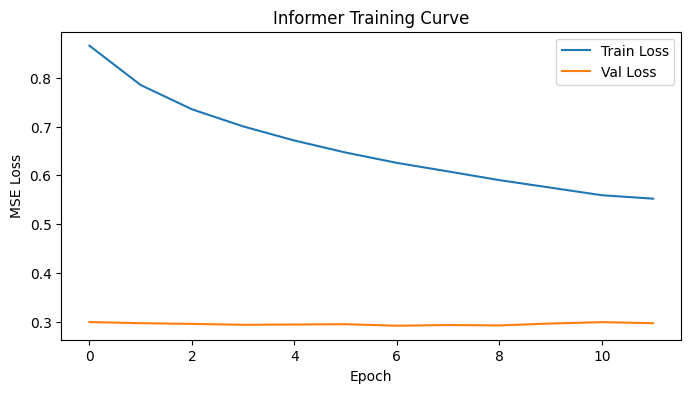

In [ ]:
# =========================
# 8. Loss curve
# =========================

plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.title("Informer Training Curve")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

In [ ]:
# =========================
# 9. Evaluation
# =========================

@torch.no_grad()
def predict_all(model, loader):
    model.eval()

    preds = []
    trues = []

    for x_enc, x_dec, y in loader:
        x_enc = x_enc.to(device)
        x_dec = x_dec.to(device)

        pred = model(x_enc, x_dec)

        preds.append(pred.cpu().numpy())
        trues.append(y.numpy())

    preds = np.concatenate(preds, axis=0)
    trues = np.concatenate(trues, axis=0)

    return preds, trues


pred_s, true_s = predict_all(model, test_loader)

pred = scaler.inverse_transform(pred_s.reshape(-1, 1)).reshape(pred_s.shape)
true = scaler.inverse_transform(true_s.reshape(-1, 1)).reshape(true_s.shape)

mae = mean_absolute_error(true.reshape(-1), pred.reshape(-1))
mse = mean_squared_error(true.reshape(-1), pred.reshape(-1))
rmse = np.sqrt(mse)

print("Test MAE :", mae)
print("Test MSE :", mse)
print("Test RMSE:", rmse)

Test MAE : 0.4094179570674896
Test MSE : 0.45787495374679565
Test RMSE: 0.6766645799410486


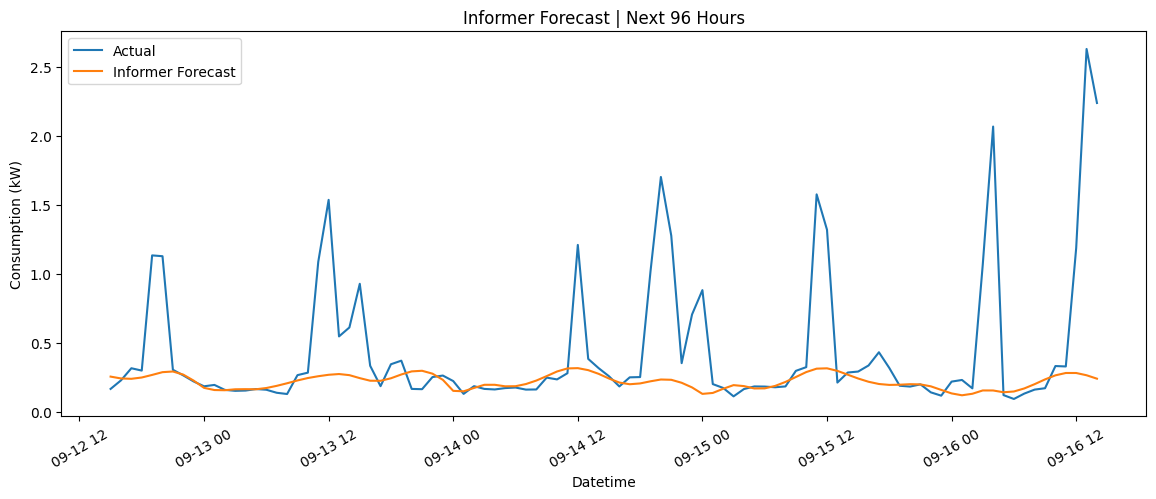

In [ ]:
# =========================
# 10. Plot one forecast
# =========================

sample_id = 0

actual = true[sample_id, :, 0]
forecast = pred[sample_id, :, 0]

future_time = dfh["datetime"].iloc[va_end + sample_id : va_end + sample_id + PRED_LEN]

plt.figure(figsize=(14, 5))
plt.plot(future_time, actual, label="Actual")
plt.plot(future_time, forecast, label="Informer Forecast")
plt.title(f"Informer Forecast | Next {PRED_LEN} Hours")
plt.xlabel("Datetime")
plt.ylabel("Consumption (kW)")
plt.legend()
plt.xticks(rotation=30)
plt.show()

In [ ]:
# =========================
# 11. Baseline comparison
# =========================

def inv(a):
    return scaler.inverse_transform(a.reshape(-1, 1)).reshape(a.shape)

all_x = []
all_y = []

for x_enc, x_dec, y in test_loader:
    all_x.append(x_enc.numpy())
    all_y.append(y.numpy())

all_x = np.concatenate(all_x, axis=0)
all_y = np.concatenate(all_y, axis=0)

x_real = all_x.copy()
x_real[:, :, 0:1] = inv(x_real[:, :, 0:1])

y_real = inv(all_y)

# Last value baseline
last_pred = np.repeat(x_real[:, -1:, 0:1], PRED_LEN, axis=1)

# Daily repeat baseline
daily_pattern = x_real[:, -24:, 0:1]
daily_pred = np.tile(daily_pattern, (1, math.ceil(PRED_LEN / 24), 1))[:, :PRED_LEN, :]

# Seasonal repeat baseline: previous PRED_LEN hours
seasonal_pred = x_real[:, -PRED_LEN:, 0:1]

def show_metrics(name, y, p):
    mae = mean_absolute_error(y.reshape(-1), p.reshape(-1))
    mse = mean_squared_error(y.reshape(-1), p.reshape(-1))
    rmse = np.sqrt(mse)

    print(name)
    print("MAE :", mae)
    print("MSE :", mse)
    print("RMSE:", rmse)
    print()

print("===== Model and Baseline Comparison =====")
show_metrics("Informer", true, pred)
show_metrics("Last Value Baseline", y_real, last_pred)
show_metrics("Daily Repeat Baseline", y_real, daily_pred)
show_metrics("Seasonal Repeat Baseline", y_real, seasonal_pred)

===== Model and Baseline Comparison =====
Informer
MAE : 0.4094179570674896
MSE : 0.45787495374679565
RMSE: 0.6766645799410486

Last Value Baseline
MAE : 0.5498905181884766
MSE : 0.7349845767021179
RMSE: 0.8573124148769327

Daily Repeat Baseline
MAE : 0.4440566301345825
MSE : 0.548713207244873
RMSE: 0.7407517851783234

Seasonal Repeat Baseline
MAE : 0.47808024287223816
MSE : 0.6123141050338745
RMSE: 0.7825050191748769



In [ ]:
# Run this cell after your InformerDataset, InformerModel, preprocessing, and split variables are already defined.

import copy, gc
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.metrics import mean_absolute_error, mean_squared_error

HORIZONS = [1, 8, 16, 24]
EPOCHS_RUN = 10

def make_loaders(pred_len):
    tr_ds = InformerDataset(train_x, train_y, SEQ_LEN, LABEL_LEN, pred_len)
    va_ds = InformerDataset(val_x, val_y, SEQ_LEN, LABEL_LEN, pred_len)
    te_ds = InformerDataset(test_x, test_y, SEQ_LEN, LABEL_LEN, pred_len)

    tr_loader = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True)
    va_loader = DataLoader(va_ds, batch_size=BATCH_SIZE, shuffle=False)
    te_loader = DataLoader(te_ds, batch_size=BATCH_SIZE, shuffle=False)

    return tr_loader, va_loader, te_loader


@torch.no_grad()
def test_metrics(model, loader):
    model.eval()

    preds = []
    trues = []

    for x_enc, x_dec, y in loader:
        x_enc = x_enc.to(device)
        x_dec = x_dec.to(device)

        pred = model(x_enc, x_dec)

        preds.append(pred.cpu().numpy())
        trues.append(y.numpy())

    preds = np.concatenate(preds, axis=0)
    trues = np.concatenate(trues, axis=0)

    preds = scaler.inverse_transform(preds.reshape(-1, 1)).reshape(preds.shape)
    trues = scaler.inverse_transform(trues.reshape(-1, 1)).reshape(trues.shape)

    mae = mean_absolute_error(trues.reshape(-1), preds.reshape(-1))
    mse = mean_squared_error(trues.reshape(-1), preds.reshape(-1))

    return mae, mse


def train_one_horizon(pred_len):
    print("\n" + "=" * 50)
    print(f"Training Informer for {pred_len} hour forecast")
    print("=" * 50)

    tr_loader, va_loader, te_loader = make_loaders(pred_len)

    model = InformerModel(
        input_dim=INPUT_DIM,
        output_dim=OUTPUT_DIM,
        pred_len=pred_len,
        d_model=D_MODEL,
        n_heads=N_HEADS,
        e_layers=E_LAYERS,
        d_layers=D_LAYERS,
        d_ff=D_FF,
        factor=FACTOR,
        dropout=DROPOUT
    ).to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    best_val = float("inf")
    best_state = None

    for epoch in range(1, EPOCHS_RUN + 1):
        model.train()
        train_loss = 0.0

        for x_enc, x_dec, y in tr_loader:
            x_enc = x_enc.to(device)
            x_dec = x_dec.to(device)
            y = y.to(device)

            optimizer.zero_grad()

            pred = model(x_enc, x_dec)
            loss = criterion(pred, y)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            train_loss += loss.item() * x_enc.size(0)

        train_loss /= len(tr_loader.dataset)

        model.eval()
        val_loss = 0.0

        with torch.no_grad():
            for x_enc, x_dec, y in va_loader:
                x_enc = x_enc.to(device)
                x_dec = x_dec.to(device)
                y = y.to(device)

                pred = model(x_enc, x_dec)
                loss = criterion(pred, y)

                val_loss += loss.item() * x_enc.size(0)

        val_loss /= len(va_loader.dataset)

        print(f"Epoch [{epoch}/{EPOCHS_RUN}] Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

        if val_loss < best_val:
            best_val = val_loss
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)

    mae, mse = test_metrics(model, te_loader)

    print(f"\nInformer {pred_len} hour forecast")
    print("MAE:", mae)
    print("MSE:", mse)

    return mae, mse


results = []

for h in HORIZONS:
    mae, mse = train_one_horizon(h)
    results.append({
        "Horizon": h,
        "MAE": mae,
        "MSE": mse
    })

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

results_df = pd.DataFrame(results)

print("\nFinal Informer Results")
display(results_df)


Training Informer for 1 hour forecast
Epoch [1/10] Train Loss: 0.853564 | Val Loss: 0.302784
Epoch [2/10] Train Loss: 0.597504 | Val Loss: 0.245643
Epoch [3/10] Train Loss: 0.518542 | Val Loss: 0.244423
Epoch [4/10] Train Loss: 0.496989 | Val Loss: 0.253271
Epoch [5/10] Train Loss: 0.483913 | Val Loss: 0.224641
Epoch [6/10] Train Loss: 0.465319 | Val Loss: 0.227115
Epoch [7/10] Train Loss: 0.457586 | Val Loss: 0.223402
Epoch [8/10] Train Loss: 0.456718 | Val Loss: 0.230758
Epoch [9/10] Train Loss: 0.446970 | Val Loss: 0.227254
Epoch [10/10] Train Loss: 0.444704 | Val Loss: 0.218335

Informer 1 hour forecast
MAE: 0.256252259016037
MSE: 0.18191401660442352

Training Informer for 8 hour forecast
Epoch [1/10] Train Loss: 0.850019 | Val Loss: 0.293583
Epoch [2/10] Train Loss: 0.755881 | Val Loss: 0.289196
Epoch [3/10] Train Loss: 0.710498 | Val Loss: 0.281019
Epoch [4/10] Train Loss: 0.683408 | Val Loss: 0.276430
Epoch [5/10] Train Loss: 0.666340 | Val Loss: 0.271766
Epoch [6/10] Train Los

,Horizon,MAE,MSE
0,1,0.256252,0.181914
1,8,0.340351,0.293245
2,16,0.367206,0.330628
3,24,0.391100,0.405522
